In [90]:
%pip install numpy
%pip install pandas
%pip install matplotlib
%pip install astropy
%pip install scipy
%pip install scikit-learn
%pip install gudhi

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [91]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import linalg
import astropy
import math

In [92]:
data = pd.read_csv('M101.csv')
data.head()

mag_data = data['inst_vega_mag2'].values
diff_data = data['inst_vega_mag1'].values - mag_data
y_data = data['inst_vega_mag1'].values
x_data = -1 * diff_data

## Task 1: GLOESS Smoothed Luminosity Function

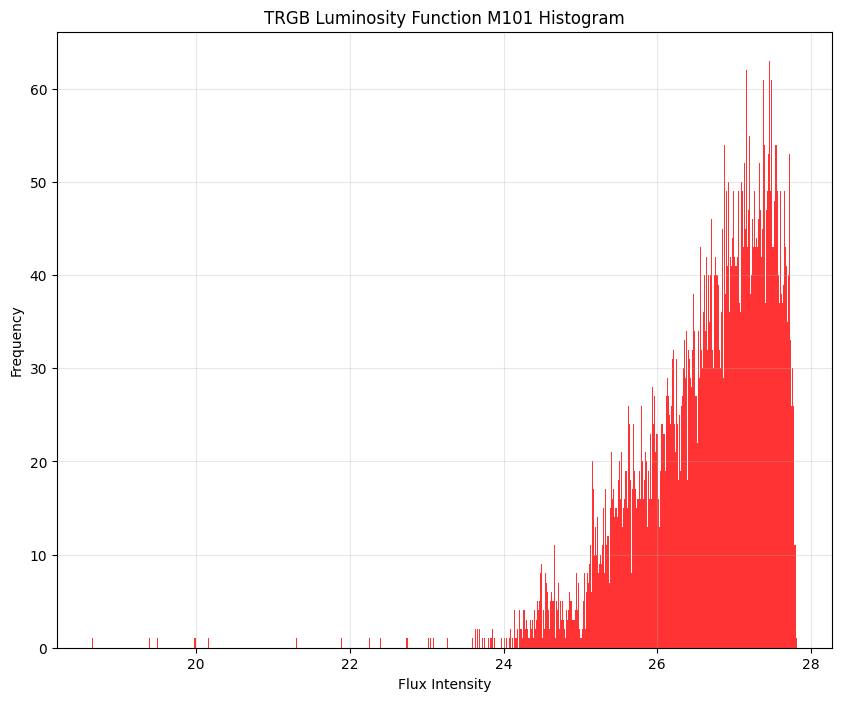

In [93]:
fig_hist, ax_hist = plt.subplots(figsize=(10, 8))

ax_hist.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.8)
ax_hist.set_xlabel('Flux Intensity')
ax_hist.set_ylabel('Frequency')
ax_hist.grid(True, alpha=0.3)
ax_hist.set_title('TRGB Luminosity Function M101 Histogram')

fig_hist.savefig('TRGB Luminosity Function M101 Histogram')

In [94]:
def gloess(mag, tau, bin_width = 0.01):
    fig_gloess, ax_gloess = plt.subplots(figsize = (10, 10))
    hist, bins, cont = ax_gloess.hist(mag, bins = np.arange(min(mag), max(mag) + bin_width, bin_width), color = 'black')
    plt.close()
    bin_centers = []
    for j in range(len(bins) - 1):
        bin_centers.append((bins[j] + bins[j + 1]) / 2)
    yest = np.zeros(len(hist))
    w = np.array([np.exp(- (bin_centers - bin_centers[i])**2/(2 * tau**2)) for i in range(len(hist))])
    for i in range(len(hist)):
        weights = w[i, :]
        b = np.array([np.sum(weights * hist), np.sum(weights * hist * bin_centers)])
        A = np.array([[np.sum(weights), np.sum(weights * bin_centers)],
                    [np.sum(weights * bin_centers), np.sum(weights * bin_centers * bin_centers)]])
        theta = linalg.solve(A, b)
        yest[i] = theta[0] + theta[1] * bin_centers[i]
    return yest, np.array(bin_centers)

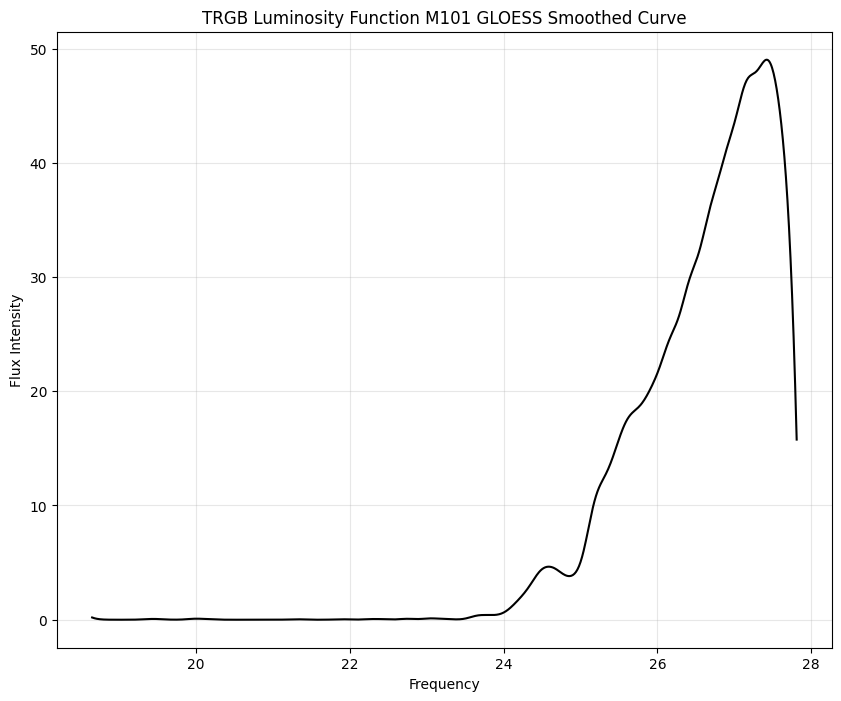

In [95]:
fig_sm, ax_sm = plt.subplots(figsize=(10, 8))

Y, X = gloess(mag_data, 0.10)
ax_sm.plot(X, Y, color='black')
ax_sm.set_ylabel('Flux Intensity')
ax_sm.set_xlabel('Frequency')
ax_sm.grid(True, alpha=0.3)
ax_sm.set_title('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

fig_sm.savefig('TRGB Luminosity Function M101 GLOESS Smoothed Curve')

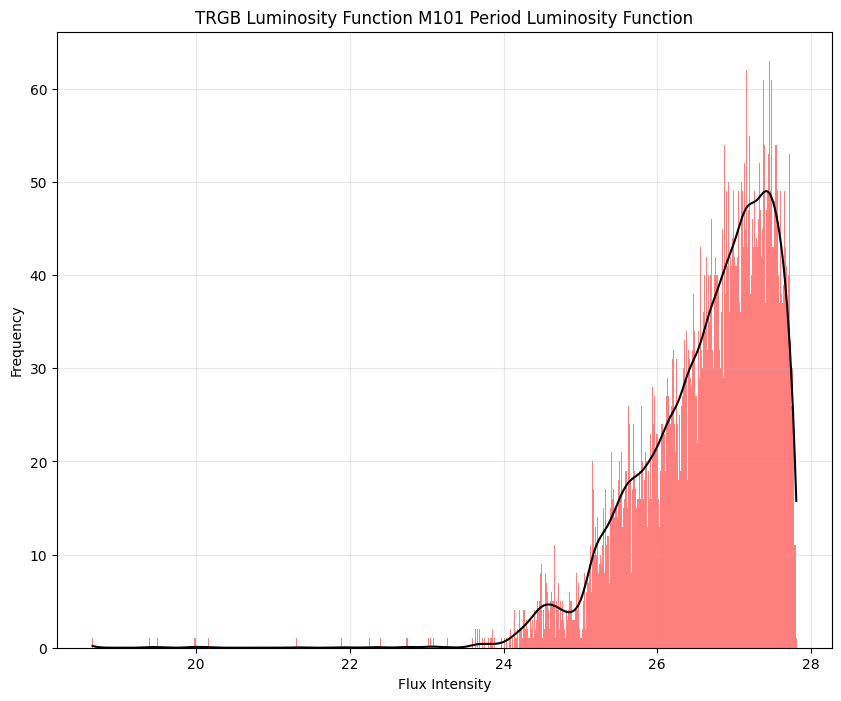

In [96]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='red', alpha=0.5)
ax.plot(X, Y, color='black')
ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Frequency')
ax.grid(True, alpha=0.3)
ax.set_title('TRGB Luminosity Function M101 Period Luminosity Function')

fig.savefig('TRGB Luminosity Function M101 Period Luminosity Function')

## Task 2: Sobel Response

In [97]:
def sobel_filter(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii-1] * -1 + hist[ii+1])
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def poisson_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append(hist[ii - 1] * -1 * 1/np.sqrt(hist[ii - 1]) + hist[ii] * 0 + hist[ii + 1] * 1* 1/np.sqrt(hist[ii + 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

def hatt_sobel(hist):
    sobel = []
    for ii in range(2, len(hist) - 2):
        sobel.append((hist[ii + 1] - hist[ii - 1]) / np.sqrt(hist[ii + 1] + hist[ii - 1]))
    sobel = np.array(sobel)
    return hist[2: -2], sobel

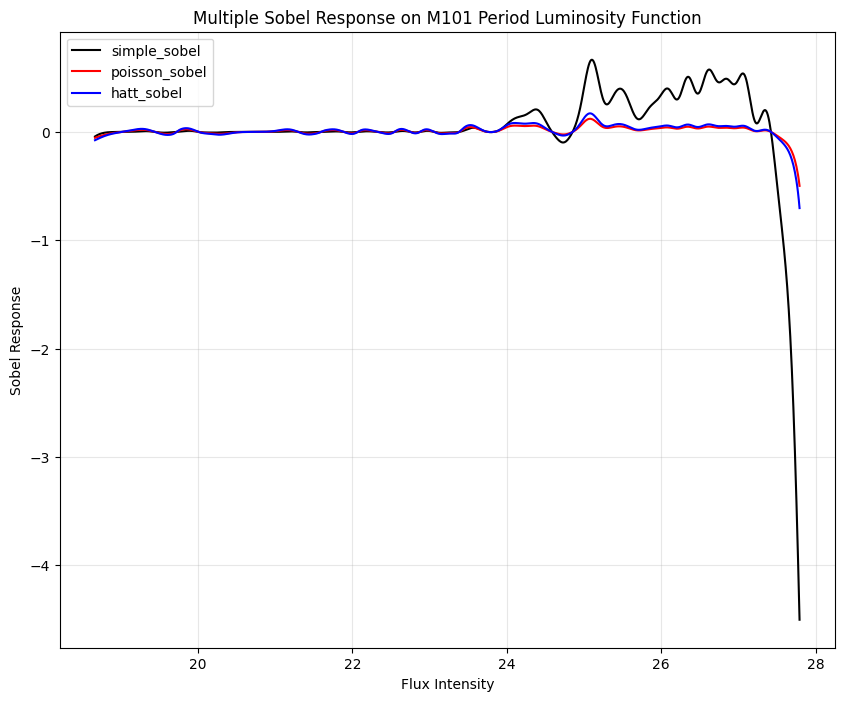

In [98]:
fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(X[2: -2], sobel_filter(Y)[1], color='black', label='simple_sobel')
ax.plot(X[2:-2], poisson_sobel(Y)[1], color='red', label='poisson_sobel')
ax.plot(X[2:-2], hatt_sobel(Y)[1], color='blue', label='hatt_sobel')
ax.legend()

ax.set_xlabel('Flux Intensity')
ax.set_ylabel('Sobel Response')
ax.set_title('Multiple Sobel Response on M101 Period Luminosity Function')
ax.grid(True, alpha=0.3)
fig.savefig('Multiple Sobel Response on M101 Period Luminosity Function')

## Task 3: Color Magnitude Diagrams and Assembled Plots


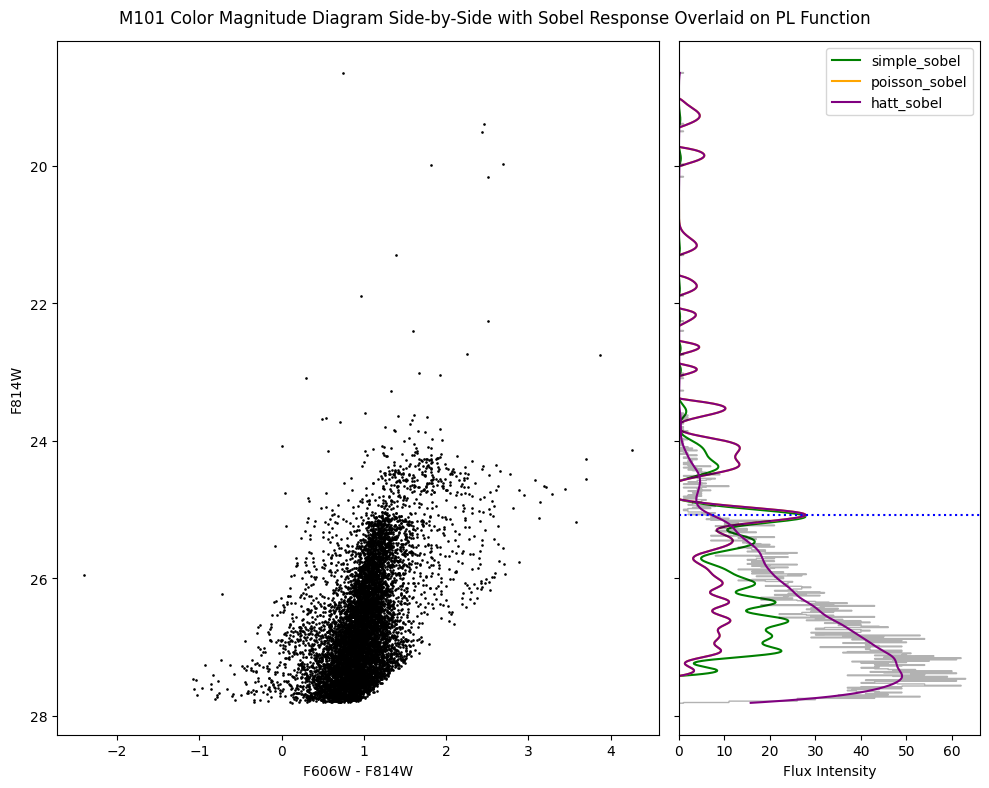

In [99]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 8), sharey=True, gridspec_kw={'width_ratios': [2, 1]})

# CMD
ax1.scatter(diff_data, mag_data, color='black', s=0.8)
ax1.yaxis.set_inverted(True)
ax1.set_xlabel('F606W - F814W')
ax1.set_ylabel('F814W')

# sobel response
scaling_factor_hatt = np.max(mag_data) / np.max(hatt_sobel(Y)[1]) # this is for visual scaling (hatt)
scaling_factor_simple = np.max(mag_data) / np.max(sobel_filter(Y)[1]) # this is for visual scaling (simple)
scaling_factor_poisson = np.max(mag_data) / np.max(poisson_sobel(Y)[1]) # this is for visual scaling (poisson)
ax2.plot(np.maximum(scaling_factor_simple * sobel_filter(Y)[1], 0), X[2:-2], color='green', label='simple_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_poisson * poisson_sobel(Y)[1], 0), X[2:-2], color='orange', label='poisson_sobel') # hatt sobel response > 0
ax2.plot(np.maximum(scaling_factor_hatt * hatt_sobel(Y)[1], 0), X[2:-2], color='purple', label='hatt_sobel') # hatt sobel response > 0
ax2.yaxis.set_inverted(True)
ax2.legend()

# histogram and gloess smoothed curve
Y, X = gloess(mag_data, 0.10)
ax2.hist(mag_data, bins=np.arange(min(mag_data), max(mag_data) + 0.01, 0.01), color='black', alpha=0.3, orientation='horizontal', histtype='step', label='pl_histogram')
ax2.plot(Y, X, color='purple', label='smoothed_pl_function')

# maximum sobel response finder
max_sobel_response = np.max(hatt_sobel(Y)[1])
max_ind = np.where(hatt_sobel(Y)[1] == max_sobel_response)
max_val = (X[2: -2])[max_ind]
ax2.axhline(y=max_val, linestyle=':', color='blue')

ax2.set_xlabel('Flux Intensity')

fig.suptitle('M101 Color Magnitude Diagram Side-by-Side with Sobel Response Overlaid on PL Function')
fig.tight_layout()
fig.savefig('M101 Color Magnitude Diagram Side-by-Side with Sobel Response Overlaid on PL Function')

## Intermittent Task: Persistent Homology TRGB Detector

Treat the GLOESS-smoothed luminosity function `Y(X)` as a 1-D signal. The TRGB
discontinuity is a sharp positive peak in `dY/dX` (which is exactly what the
Sobel filters approximate). We define `g(m) = -|dY/dm|` so that the Sobel-style
peak becomes a deep minimum, and run **sublevel-set persistence** on `g` with
GUDHI's `CubicalComplex`. Each connected component (H0 class) is born at a
local minimum and dies when it merges with a deeper neighbor; its **persistence**
(`death - birth`) is the prominence of that minimum.

The most persistent finite-lifetime H0 class corresponds to the dominant peak in
`|dY/dm|` — the TRGB tip. Persistence diagrams give us a principled way to
separate the tip from Poisson noise (signal sits far from the diagonal; noise
sits near it), and bootstrap-resampling the catalogue yields error bars on the
tip magnitude.

In [100]:
import gudhi


def lf_signal(X, Y, mag_window=None):
    """Build g(m) = -|dY/dm| on the same grid as X (interior points only).

    If mag_window=(m_lo, m_hi) is given, restrict the signal to that magnitude
    range before persistence — necessary to avoid PH locking onto the
    photometric-completeness fall-off at the faint end (or saturation at the
    bright end) instead of the TRGB tip.
    """
    dY = (Y[2:] - Y[:-2]) / (X[2:] - X[:-2])  # central diff
    g = -np.abs(dY)
    Xg = X[1:-1]
    if mag_window is not None:
        m_lo, m_hi = mag_window
        mask = (Xg >= m_lo) & (Xg <= m_hi)
        Xg = Xg[mask]
        g = g[mask]
    return Xg, g


def ph_tip(X, Y, mag_window=None):
    """Return (tip_magnitude, sorted_pairs, signal_X, signal_g).

    sorted_pairs is a list of (birth, death, persistence, idx) for H0, sorted by
    persistence descending. The first finite-persistence pair corresponds to
    the dominant minimum of g, i.e. the TRGB tip. mag_window restricts the
    search to a magnitude range (e.g. the RGB region).
    """
    Xg, g = lf_signal(X, Y, mag_window=mag_window)
    cc = gudhi.CubicalComplex(top_dimensional_cells=g)
    cc.persistence(homology_coeff_field=2, min_persistence=0)

    regular, essential = cc.cofaces_of_persistence_pairs()
    h0_pairs = []
    if len(regular) > 0:
        for birth_idx, death_idx in regular[0]:
            b, d = g[birth_idx], g[death_idx]
            h0_pairs.append((b, d, d - b, birth_idx))

    h0_pairs.sort(key=lambda p: p[2], reverse=True)
    if not h0_pairs:
        return np.nan, [], Xg, g
    tip_idx = h0_pairs[0][3]
    return Xg[tip_idx], h0_pairs, Xg, g


# RGB magnitude window for M101: excludes saturation (bright end) and the
# completeness fall-off past ~26.5. Tune if PH locks onto a non-TRGB feature.
RGB_WINDOW = (22.0, 26.0)

PH    tip (F814W) = 25.990
Sobel tip (F814W) = 25.080
Top 5 H0 persistences: [np.float64(10.9129), np.float64(10.242), np.float64(7.254), np.float64(4.6803), np.float64(1.9279)]


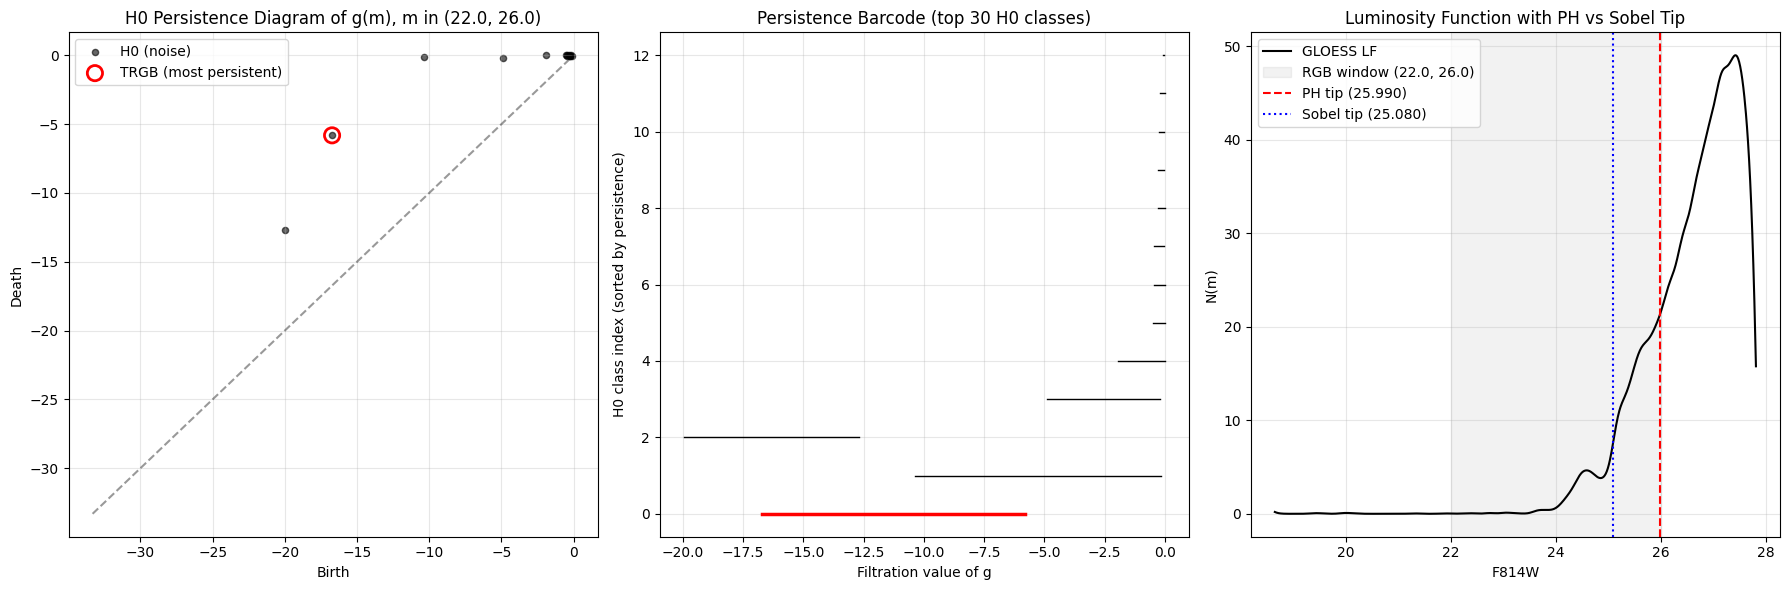

In [101]:
Y, X = gloess(mag_data, 0.10)
ph_mag, h0_pairs, Xg, g = ph_tip(X, Y, mag_window=RGB_WINDOW)

# Sobel reference tip from Task 3 (Hatt), restricted to the same RGB window
hatt_resp = hatt_sobel(Y)[1]
X_hatt = X[2:-2]
hatt_mask = (X_hatt >= RGB_WINDOW[0]) & (X_hatt <= RGB_WINDOW[1])
sobel_mag = X_hatt[hatt_mask][np.argmax(hatt_resp[hatt_mask])]

print(f"PH    tip (F814W) = {ph_mag:.3f}")
print(f"Sobel tip (F814W) = {sobel_mag:.3f}")
print(f"Top 5 H0 persistences: {[round(p[2], 4) for p in h0_pairs[:5]]}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

births = np.array([p[0] for p in h0_pairs])
deaths = np.array([p[1] for p in h0_pairs])
finite = np.isfinite(deaths)
axes[0].scatter(births[finite], deaths[finite], s=20, color='black', alpha=0.6, label='H0 (noise)')
if finite.any():
    top_b, top_d = h0_pairs[0][0], h0_pairs[0][1]
    axes[0].scatter([top_b], [top_d], s=120, edgecolor='red', facecolor='none', linewidth=2, label='TRGB (most persistent)')
lo, hi = float(np.min(g)), float(np.max(g))
axes[0].plot([lo, hi], [lo, hi], 'k--', alpha=0.4)
axes[0].set_xlabel('Birth')
axes[0].set_ylabel('Death')
axes[0].set_title(f'H0 Persistence Diagram of g(m), m in {RGB_WINDOW}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

for i, (b, d, p, _) in enumerate(h0_pairs[:30]):
    if not np.isfinite(d):
        continue
    color = 'red' if i == 0 else 'black'
    lw = 2.5 if i == 0 else 1.0
    axes[1].plot([b, d], [i, i], color=color, lw=lw)
axes[1].set_xlabel('Filtration value of g')
axes[1].set_ylabel('H0 class index (sorted by persistence)')
axes[1].set_title('Persistence Barcode (top 30 H0 classes)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(X, Y, color='black', label='GLOESS LF')
axes[2].axvspan(RGB_WINDOW[0], RGB_WINDOW[1], color='gray', alpha=0.1, label=f'RGB window {RGB_WINDOW}')
axes[2].axvline(ph_mag, color='red', linestyle='--', label=f'PH tip ({ph_mag:.3f})')
axes[2].axvline(sobel_mag, color='blue', linestyle=':', label=f'Sobel tip ({sobel_mag:.3f})')
axes[2].set_xlabel('F814W')
axes[2].set_ylabel('N(m)')
axes[2].set_title('Luminosity Function with PH vs Sobel Tip')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig('TRGB Persistent Homology Diagnostic')

Bootstrap PH tip = 25.951  (+0.048 / -1.562) over 200 samples


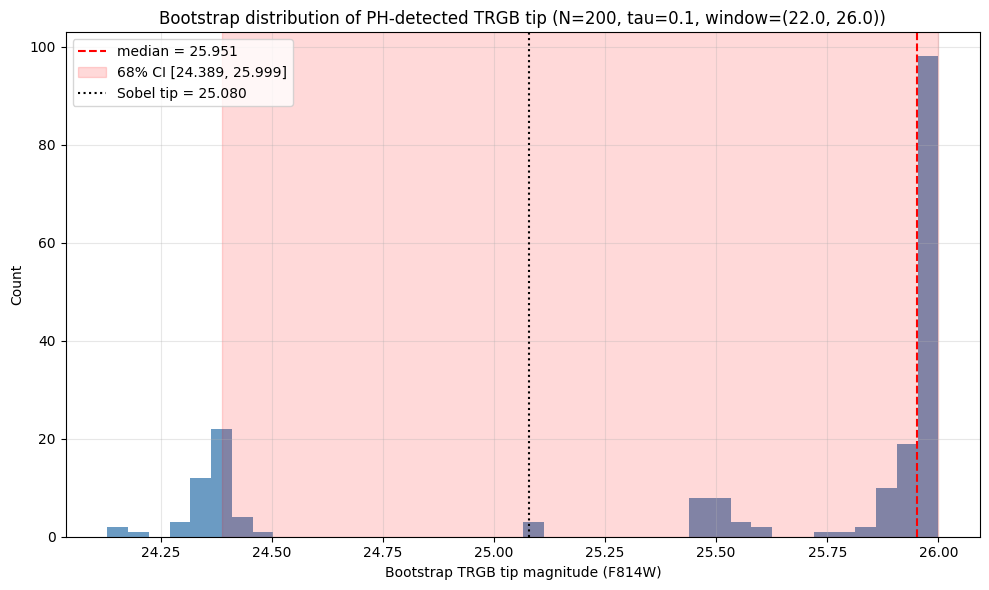

In [102]:
rng = np.random.default_rng(42)
N_BOOT = 200
TAU = 0.10

mag_arr = data['inst_vega_mag2'].values
err_arr = data['mag2_err'].values
n = len(mag_arr)

boot_tips = []
for b in range(N_BOOT):
    idx = rng.integers(0, n, size=n)
    sample = mag_arr[idx] + rng.normal(0, err_arr[idx])
    Yb, Xb = gloess(sample, TAU)
    tip_b, _, _, _ = ph_tip(Xb, Yb, mag_window=RGB_WINDOW)
    boot_tips.append(tip_b)

boot_tips = np.array(boot_tips)
boot_tips = boot_tips[np.isfinite(boot_tips)]

med = np.median(boot_tips)
lo, hi = np.percentile(boot_tips, [16, 84])
print(f"Bootstrap PH tip = {med:.3f}  (+{hi-med:.3f} / -{med-lo:.3f}) over {len(boot_tips)} samples")

fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(boot_tips, bins=40, color='steelblue', alpha=0.8)
ax.axvline(med, color='red', linestyle='--', label=f'median = {med:.3f}')
ax.axvspan(lo, hi, color='red', alpha=0.15, label=f'68% CI [{lo:.3f}, {hi:.3f}]')
ax.axvline(sobel_mag, color='black', linestyle=':', label=f'Sobel tip = {sobel_mag:.3f}')
ax.set_xlabel('Bootstrap TRGB tip magnitude (F814W)')
ax.set_ylabel('Count')
ax.set_title(f'Bootstrap distribution of PH-detected TRGB tip (N={len(boot_tips)}, tau={TAU}, window={RGB_WINDOW})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('TRGB Persistent Homology Bootstrap')

tau=0.05  PH=25.490  Sobel=25.090  diff=+0.400
tau=0.10  PH=25.990  Sobel=25.080  diff=+0.910
tau=0.15  PH=24.320  Sobel=25.080  diff=-0.760
tau=0.20  PH=24.280  Sobel=25.110  diff=-0.830


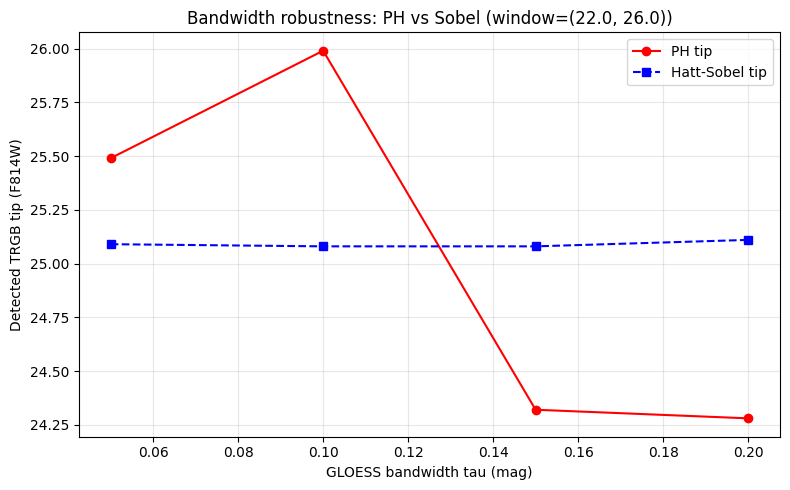

In [103]:
taus = [0.05, 0.10, 0.15, 0.20]
ph_by_tau = []
sobel_by_tau = []
for t in taus:
    Yt, Xt = gloess(mag_data, t)
    ph_t, _, _, _ = ph_tip(Xt, Yt, mag_window=RGB_WINDOW)
    Xh = Xt[2:-2]
    h_mask = (Xh >= RGB_WINDOW[0]) & (Xh <= RGB_WINDOW[1])
    h_resp = hatt_sobel(Yt)[1]
    sob_t = Xh[h_mask][np.argmax(h_resp[h_mask])]
    ph_by_tau.append(ph_t)
    sobel_by_tau.append(sob_t)
    print(f"tau={t:.2f}  PH={ph_t:.3f}  Sobel={sob_t:.3f}  diff={ph_t-sob_t:+.3f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(taus, ph_by_tau, 'o-', color='red', label='PH tip')
ax.plot(taus, sobel_by_tau, 's--', color='blue', label='Hatt-Sobel tip')
ax.set_xlabel('GLOESS bandwidth tau (mag)')
ax.set_ylabel('Detected TRGB tip (F814W)')
ax.set_title(f'Bandwidth robustness: PH vs Sobel (window={RGB_WINDOW})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig('TRGB Persistent Homology Bandwidth Robustness')